**LAB NO: 06**

**Aim**

To build and train an Artificial Neural Network (ANN) using TensorFlow for classification using an inbuilt dataset.

**Theory**

What is a Neural Network?

A Neural Network consists of:

Input Layer

Hidden Layer(s)

Output Layer

Each layer contains neurons connected by weights.

Mathematically:

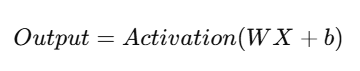

**Activation Functions**

ReLU → Used in hidden layers

Softmax → Used for multiclass classification

Sigmoid → Used for binary classification

**Dataset Used**

We use inbuilt dataset:

MNIST dataset

70,000 grayscale images

10 classes (digits 0–9)

Image size: 28 × 28

**Software Requirements**

Google Colab

Python 3.x

TensorFlow 2.19

**Algorithm**

Import libraries

Load MNIST dataset

Normalize data

Build Neural Network model

Compile model

Train model

Evaluate accuracy

Visualize performance

TensorFlow Version: 2.19.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (60000, 28, 28)
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8674 - loss: 0.4437 - val_accuracy: 0.9687 - val_loss: 0.1057
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9673 - loss: 0.1092 - val_accuracy: 0.9710 - val_loss: 0.0932
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9765 - loss: 0.0730 - val_accuracy: 0.9730 - val_loss: 0.0819
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9826 - loss: 0.0548 - val_accuracy: 0.9787 - val_loss: 0.0770
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9867 - loss: 0.0409 - val_accuracy: 0.9778 - val_loss: 0.0778
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9733 - loss: 0.0867
Test Accuracy: 0.9775000214576721
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


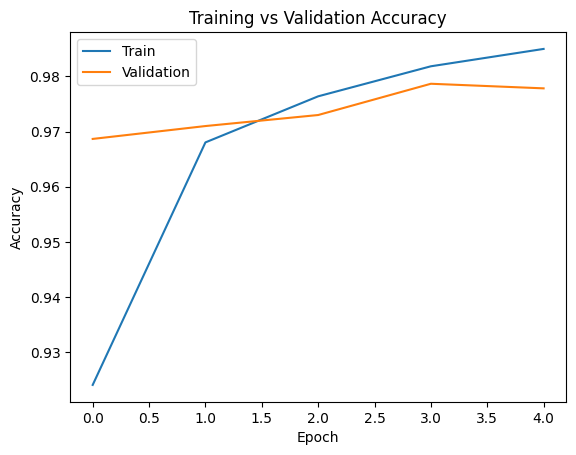

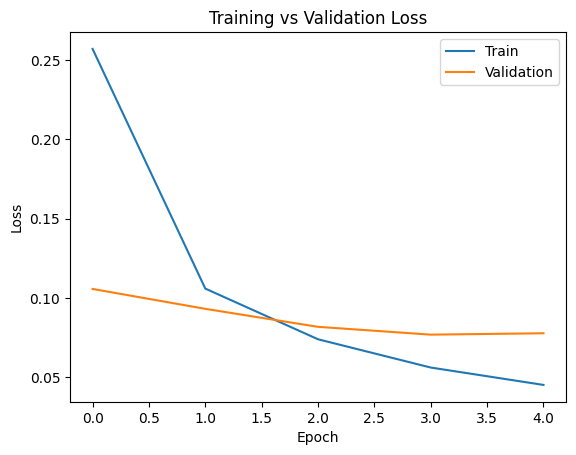

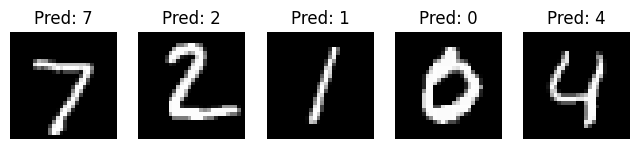

In [1]:
# ==========================================
# NEURAL NETWORK USING TENSORFLOW (MNIST)
# ==========================================

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow Version:", tf.__version__)

# Step 1: Load MNIST Dataset
(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.mnist.load_data()

print("Training Data Shape:", X_train.shape)

# Step 2: Normalize (0-255 → 0-1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Step 3: Build Neural Network Model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28,28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Step 4: Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Step 5: Train Model
history = model.fit(X_train, Y_train, epochs=5, validation_split=0.1)

# Step 6: Evaluate Model
loss, accuracy = model.evaluate(X_test, Y_test)
print("Test Accuracy:", accuracy)

# Step 7: Predictions
predictions = model.predict(X_test)

# ==========================
# VISUALIZATION SECTION
# ==========================

# 1️⃣ Accuracy Curve
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# 2️⃣ Loss Curve
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

# 3️⃣ Show Sample Predictions
plt.figure(figsize=(8,4))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title("Pred: " + str(np.argmax(predictions[i])))
    plt.axis('off')
plt.show()
